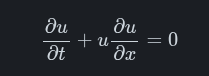

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time, sys

%matplotlib inline

# solver setup

domain = 2
nx = 201
dx = domain / (nx - 1)

nt = 20

# initial conditions

u = np.ones(nx)
u[int(0.5 / dx) : int((1 / dx) + 1)] = 2

# define CFL to deduce dt from nx so we don't nuke the solver

CFL = 0.9
dt = CFL * dx / max(abs(u))
print(dt)

0.0045000000000000005


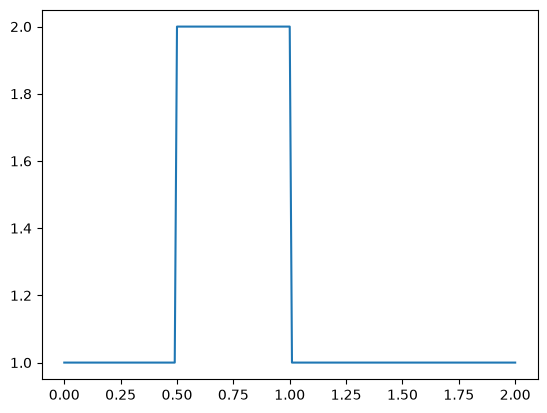

In [2]:
plt.plot(np.linspace(0, domain, nx), u);
plt.show()

In [3]:
un = np.ones(nx)

for n in range(nt):
    un = u.copy()
    u[1:] = un[1:] - (dt / dx) * un[1:] * (un[1:] - un[0:-1])

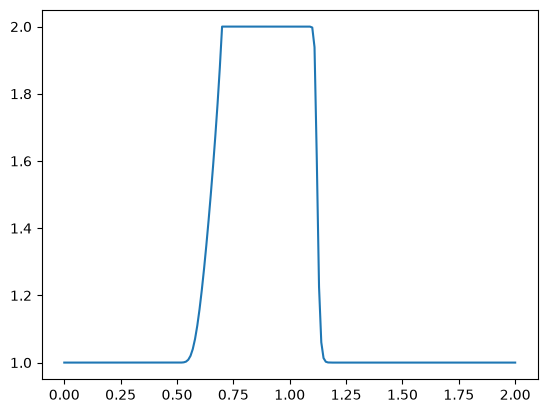

In [4]:
plt.plot(np.linspace(0, domain, nx), u)
plt.show()

In [5]:
# reversing the wave direction

u = np.ones(nx)
u[:] = -1
u[int(0.75 / dx):int((1.25 / dx) + 1)] = -2

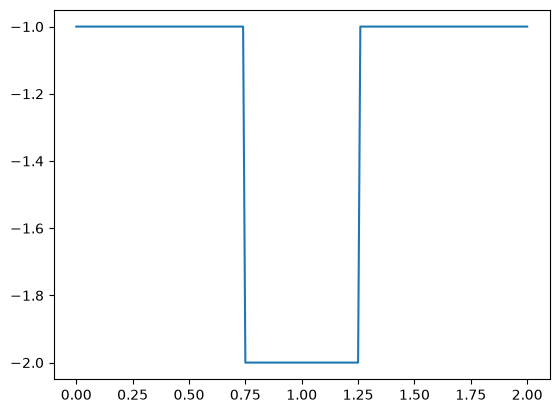

In [6]:
plt.plot(np.linspace(0, domain, nx), u)
plt.show()

In [7]:
for n in range(nt):
    un = u.copy()
    
    backward = un > 0
    forward = un < 0
    
    u[1:] = np.where(backward[1:], un[1:] - (dt/dx) * un[1:] * (un[1:] - un[:-1]), u[1:])
    
    u[:-1] = np.where(forward[:-1], un[:-1] - (dt/dx) * un[:-1] * (un[1:] - un[:-1]), u[:-1])

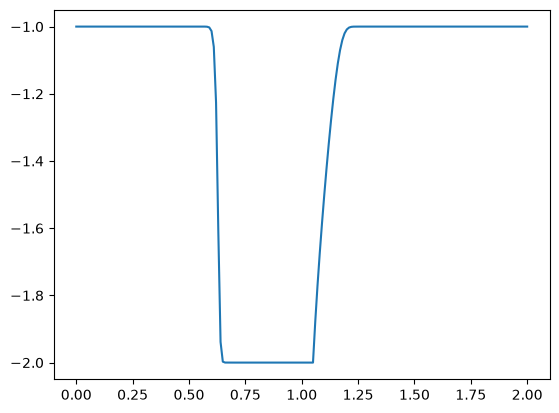

In [8]:
plt.plot(np.linspace(0, domain, nx), u)
plt.show()